Import packages and initial configuration

In [ ]:
import pandas as pd
import os
import datasets
from datetime import datetime
from datasets import load_dataset, get_dataset_config_names, interleave_datasets
import re
import random
import seaborn as sns
import matplotlib.pyplot as plt
from langdetect import detect, DetectorFactory

# optimize printed dataframes
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

Selection of Top-10 Product categories

In [ ]:
dataset_id = "McAuley-Lab/Amazon-Reviews-2023" # state dataset id
all_configs = get_dataset_config_names(dataset_id)
all_configs

#loop through dataset conifg to get see all avaible product catgories
filtered = [c for c in all_configs if re.match(r"^raw_review", c)]
filtered

top_10 = ['raw_review_Clothing_Shoes_and_Jewelry', 'raw_review_Home_and_Kitchen', 'raw_review_Electronics', 
          'raw_review_Health_and_Household', 'raw_review_Cell_Phones_and_Accessories', 'raw_review_Beauty_and_Personal_Care',
           'raw_review_Tools_and_Home_Improvement', 'raw_review_Books', 'raw_review_Kindle_Store', 'raw_review_Automotive'
           ]


Using the latest cached version of the module from /Users/philipp/.cache/huggingface/modules/datasets_modules/datasets/McAuley-Lab--Amazon-Reviews-2023/16b76e0823d73bb8cff1e9c5e3e37dbc46ae3daee380417ae141f5e67d3ea8e8 (last modified on Sat Apr 25 22:19:12 2026) since it couldn't be found locally at McAuley-Lab/Amazon-Reviews-2023, or remotely on the Hugging Face Hub.


## Dataset extraction

In [ ]:
# state category sizes
category_sizes = {
    "raw_review_Home_and_Kitchen": 67_400_000,
    "raw_review_Clothing_Shoes_and_Jewelry": 66_000_000,
    "raw_review_Electronics": 43_900_000,
    "raw_review_Books": 29_500_000,
    "raw_review_Tools_and_Home_Improvement": 27_000_000,
    "raw_review_Health_and_Household": 25_600_000,
    "raw_review_Kindle_Store": 25_600_000,
    "raw_review_Beauty_and_Personal_Care": 23_900_000,
    "raw_review_Cell_Phones_and_Accessories": 20_800_000,
    "raw_review_Automotive": 20_000_000
}

# only pull a fraction of the full dataset
SAMPLE_RATE = 0.001


take_sizes = {
    x: max(100, int(size * SAMPLE_RATE))
    for x, size in category_sizes.items()
}

# necessary columns to keep
keep_columns = ['rating', 'title', 'text', 'asin', 'parent_asin',
                'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']

# create empty df to fill later
all_dfs = []

for x in top_10:
    n = take_sizes[x]
    
    # load in data in streaming mode to not load data locally
    dataset = load_dataset(
        "McAuley-Lab/Amazon-Reviews-2023",
        x,
        split="full",
        streaming=True, # only lead data via internet
        trust_remote_code=True
    )
    
    # take a fraction of data pulled from the full set
    sampled = dataset.shuffle(seed=42, buffer_size=10_000).take(n)
    
    rows = [] # create empty row list to fill
    for row in sampled:
        filtered_row = {k: row[k] for k in keep_columns if k in row} # loop through the top-10 chosen catgories
        filtered_row["category"] = x.replace("raw_review_", "") # access different categories from the top 10 catgories
        rows.append(filtered_row) #
    
    df = pd.DataFrame(rows) # convert to dataframe
    all_dfs.append(df) # append to existing dataframe with previous reviews
    print(f"✓ {x}: {len(df):,} rows") # print number of rows we have sampled from each product category

combined_df = pd.concat(all_dfs, ignore_index=True) 
print(f"\nTotal: {len(combined_df):,} rows") # print number of rows in the dataset
combined_df.head()

✓ raw_review_Clothing_Shoes_and_Jewelry: 66,000 rows
✓ raw_review_Home_and_Kitchen: 67,400 rows
✓ raw_review_Electronics: 43,900 rows
✓ raw_review_Health_and_Household: 25,600 rows
✓ raw_review_Cell_Phones_and_Accessories: 20,800 rows
✓ raw_review_Beauty_and_Personal_Care: 23,900 rows
✓ raw_review_Tools_and_Home_Improvement: 27,000 rows
✓ raw_review_Books: 29,500 rows
✓ raw_review_Kindle_Store: 25,600 rows
✓ raw_review_Automotive: 20,000 rows

Total: 349,700 rows


,rating,title,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,category
0,3.0,"Nice shirts, run very small",I am 5’7” and weigh about 145 lbs and a 36C.ty...,B072V7BL88,B072V7BL88,AFSKPY37N3C43SOI5IEXEK5JSIYA,1522683613029,1,False,Clothing_Shoes_and_Jewelry
1,5.0,Love it,This is a great wardrobe staple. It is comfort...,B0BG19BW17,B0BFZVLSLY,AFJBKPK5W56XWSNPQU2WW66ISWYQ,1670338526788,0,False,Clothing_Shoes_and_Jewelry
2,4.0,Good for fall,"It is a good fit for normal wear, but for wear...",B074GL7ZHN,B074GL7ZHN,AEPQUIWJI7FYDURUJIDWLMPBU2KA,1575243275040,0,True,Clothing_Shoes_and_Jewelry
3,4.0,this shirt fit very nice and seems to be well ...,this shirt fit very nice and seems to be well ...,B0192Z31X6,B0192Z31X6,AHATA6X6MYTC3VNBFJ3WIYVK257A,1504220825976,0,False,Clothing_Shoes_and_Jewelry
4,5.0,"Fits well, washes nice.",This crop top sports bra looks great and fits ...,B079DZ7215,B079DZ7215,AHATA6X6MYTC3VNBFJ3WIYVK257A,1530842530233,0,False,Clothing_Shoes_and_Jewelry


## Initial data cleaning and filtering

In [ ]:
# create new variable df
df = pd.DataFrame(combined_df)
print(df.head())

# create column with human readable date and time
df['date_readable'] = pd.to_datetime(df['timestamp'], unit='ms')

# create column with date only
df['date_only'] = pd.to_datetime(df['timestamp'], unit='ms').dt.date # transform timestemp into human readable date

Fertig! Der DF hat 349700 Zeilen.
   rating                                              title                                               text        asin parent_asin                       user_id      timestamp  helpful_vote  verified_purchase                    category
0     3.0                        Nice shirts, run very small  I am 5’7” and weigh about 145 lbs and a 36C.ty...  B072V7BL88  B072V7BL88  AFSKPY37N3C43SOI5IEXEK5JSIYA  1522683613029             1              False  Clothing_Shoes_and_Jewelry
1     5.0                                            Love it  This is a great wardrobe staple. It is comfort...  B0BG19BW17  B0BFZVLSLY  AFJBKPK5W56XWSNPQU2WW66ISWYQ  1670338526788             0              False  Clothing_Shoes_and_Jewelry
2     4.0                                      Good for fall  It is a good fit for normal wear, but for wear...  B074GL7ZHN  B074GL7ZHN  AEPQUIWJI7FYDURUJIDWLMPBU2KA  1575243275040             0               True  Clothing_Shoes_and_Jewelr

In [37]:
df.head()

,rating,title,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,category,date_readable,date_only
0,3.0,"Nice shirts, run very small",I am 5’7” and weigh about 145 lbs and a 36C.ty...,B072V7BL88,B072V7BL88,AFSKPY37N3C43SOI5IEXEK5JSIYA,1522683613029,1,False,Clothing_Shoes_and_Jewelry,2018-04-02 15:40:13.029,2018-04-02
1,5.0,Love it,This is a great wardrobe staple. It is comfort...,B0BG19BW17,B0BFZVLSLY,AFJBKPK5W56XWSNPQU2WW66ISWYQ,1670338526788,0,False,Clothing_Shoes_and_Jewelry,2022-12-06 14:55:26.788,2022-12-06
2,4.0,Good for fall,"It is a good fit for normal wear, but for wear...",B074GL7ZHN,B074GL7ZHN,AEPQUIWJI7FYDURUJIDWLMPBU2KA,1575243275040,0,True,Clothing_Shoes_and_Jewelry,2019-12-01 23:34:35.040,2019-12-01
3,4.0,this shirt fit very nice and seems to be well ...,this shirt fit very nice and seems to be well ...,B0192Z31X6,B0192Z31X6,AHATA6X6MYTC3VNBFJ3WIYVK257A,1504220825976,0,False,Clothing_Shoes_and_Jewelry,2017-08-31 23:07:05.976,2017-08-31
4,5.0,"Fits well, washes nice.",This crop top sports bra looks great and fits ...,B079DZ7215,B079DZ7215,AHATA6X6MYTC3VNBFJ3WIYVK257A,1530842530233,0,False,Clothing_Shoes_and_Jewelry,2018-07-06 02:02:10.233,2018-07-06


In [ ]:
combined_df.groupby("category")["text"].count() # see count of reviews per product category

category
Automotive                     20000
Beauty_and_Personal_Care       23900
Books                          29500
Cell_Phones_and_Accessories    20800
Clothing_Shoes_and_Jewelry     66000
Electronics                    43900
Health_and_Household           25600
Home_and_Kitchen               67400
Kindle_Store                   25600
Tools_and_Home_Improvement     27000
Name: text, dtype: int64

In [ ]:
df['year'] = df['date_readable'].dt.year #create column with only the year a corresponding review was published
df.head()

,rating,title,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,category,date_readable,date_only,year
0,3.0,"Nice shirts, run very small",I am 5’7” and weigh about 145 lbs and a 36C.ty...,B072V7BL88,B072V7BL88,AFSKPY37N3C43SOI5IEXEK5JSIYA,1522683613029,1,False,Clothing_Shoes_and_Jewelry,2018-04-02 15:40:13.029,2018-04-02,2018
1,5.0,Love it,This is a great wardrobe staple. It is comfort...,B0BG19BW17,B0BFZVLSLY,AFJBKPK5W56XWSNPQU2WW66ISWYQ,1670338526788,0,False,Clothing_Shoes_and_Jewelry,2022-12-06 14:55:26.788,2022-12-06,2022
2,4.0,Good for fall,"It is a good fit for normal wear, but for wear...",B074GL7ZHN,B074GL7ZHN,AEPQUIWJI7FYDURUJIDWLMPBU2KA,1575243275040,0,True,Clothing_Shoes_and_Jewelry,2019-12-01 23:34:35.040,2019-12-01,2019
3,4.0,this shirt fit very nice and seems to be well ...,this shirt fit very nice and seems to be well ...,B0192Z31X6,B0192Z31X6,AHATA6X6MYTC3VNBFJ3WIYVK257A,1504220825976,0,False,Clothing_Shoes_and_Jewelry,2017-08-31 23:07:05.976,2017-08-31,2017
4,5.0,"Fits well, washes nice.",This crop top sports bra looks great and fits ...,B079DZ7215,B079DZ7215,AHATA6X6MYTC3VNBFJ3WIYVK257A,1530842530233,0,False,Clothing_Shoes_and_Jewelry,2018-07-06 02:02:10.233,2018-07-06,2018


In [ ]:
df.groupby("year")["text"].count() # see count of reviews per year

year
1997        5
1998       12
1999        9
2000       29
2001      180
2002      282
2003       85
2004      285
2005      319
2006      584
2007      762
2008      880
2009      885
2010     1224
2011     2117
2012     4142
2013     8488
2014    12237
2015    17480
2016    22193
2017    25352
2018    31558
2019    46329
2020    56695
2021    58635
2022    49916
2023     9017
Name: text, dtype: int64

In [ ]:
df.groupby("rating")["text"].count() # look at count of total reviews per rating

rating
1.0     19474
2.0     14140
3.0     27615
4.0     59528
5.0    228943
Name: text, dtype: int64

Filter for years and verified purchases

In [ ]:
# filter for yearrs
recent_years_df = df[df["year"] >= 2020]
recent_years_df.groupby("year")["text"].count()

# filter for verified purchases only
recent_years_df = recent_years_df[recent_years_df["verified_purchase"] == True]

Filter for English reviews

In [ ]:


# Set seed for reproducible language detection results
DetectorFactory.seed = 42

def detect_language_safe(text):
    try:
        # Returns the language code (e.g., 'en', 'de')
        return detect(str(text))
    except:
        return "unknown"

# Create the language column by applying detection to the "text" column
print("Detecting language for f['text']...")
recent_years_df['language'] = recent_years_df['text'].apply(detect_language_safe)

# Filter the data frame to keep only English entries
final_df_english = recent_years_df[recent_years_df['language'] == 'en'].copy()

# Print verification results
print(f"Total rows before filtering: {len(recent_years_df)}")
print(f"Total rows after filtering (English only): {len(final_df_english)}")
print("\nLanguage distribution:")
print(recent_years_df['language'].value_counts())

Detecting language for f['text']...
Total rows before filtering: 108946
Total rows after filtering (English only): 103582

Language distribution:
language
en         103582
af            811
ro            752
es            431
so            425
unknown       349
fr            303
ca            277
da            248
et            221
de            206
no            198
tl            147
it            133
sl            116
nl            114
pl            114
cy             89
sv             84
sq             55
pt             49
id             39
hu             38
vi             32
fi             28
sk             27
tr             23
hr             19
cs             16
sw             11
lv              7
lt              2
Name: count, dtype: int64


In [ ]:
shuffled_reduced_df = final_df_english.sample(n=5000, random_state=42).reset_index(drop=True)
# check reviews per year 
print(shuffled_reduced_df.groupby("year")["text"].count())
final_df = shuffled_reduced_df
final_df["year"] = final_df["year"].astype("category")

# select columns to drop
columns_to_drop = ["asin", "parent_asin", "timestamp", "date_readable", "helpful_vote", "user_id"]

# remove unecessary columns
final_df = final_df.drop(columns=columns_to_drop)


year
2020    1505
2021    1685
2022    1519
2023     291
Name: text, dtype: int64


## Inital EDA

Reviews per year distribution

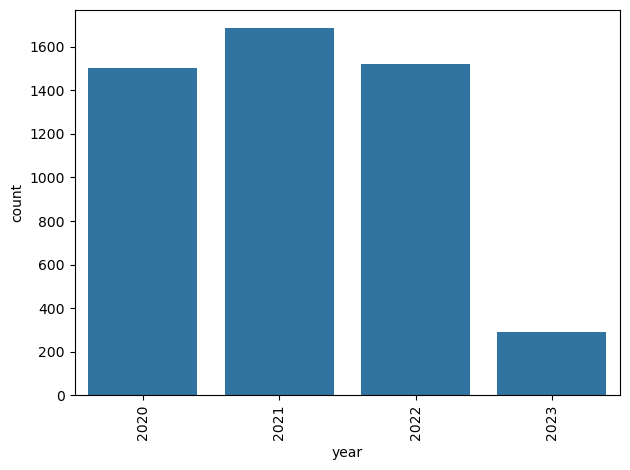

In [ ]:
# visualize distribution of reviews per year
sns.countplot(data=final_df, x="year")

# rotate x-axis labels
plt.xticks(rotation=90)
plt.tight_layout() 
plt.show()

Product rating distribution

Proportionen:
rating
5.0    0.6792
4.0    0.1160
1.0    0.0822
3.0    0.0738
2.0    0.0488
Name: proportion, dtype: float64


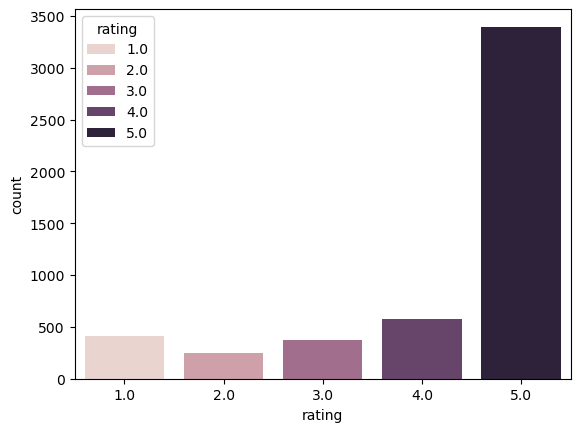

In [ ]:
sns.countplot(data=final_df, x="rating", hue="rating")

# calculate proportions of star ratings
rating_proportions = final_df["rating"].value_counts(normalize=True)

print("Proportions:")
print(rating_proportions)



In [ ]:
# create a column with the text lenght of reviews
final_df["text_length"] = final_df["text"].apply(lambda x: len(x))
final_df["label"] = 1
final_df.head()


,rating,title,text,verified_purchase,category,date_only,year,language,text_length,label
0,5.0,Best investment this summer,"Since I’m so aware of sun protection, I need a...",True,Clothing_Shoes_and_Jewelry,2022-09-06,2022,en,260,1
1,5.0,Wear socks,I have to wear socks with them. They gave me b...,True,Clothing_Shoes_and_Jewelry,2021-07-01,2021,en,71,1
2,5.0,Excellent product,"Very good quality, easy to install and works g...",True,Tools_and_Home_Improvement,2022-05-08,2022,en,51,1
3,5.0,Hair moisture,This is wonderful for my 4C hair. I will buy a...,True,Beauty_and_Personal_Care,2021-06-19,2021,en,50,1
4,5.0,Great battery,These batteries work for a really long time! W...,True,Health_and_Household,2021-05-13,2021,en,113,1


In [48]:
final_df.head()

,rating,title,text,verified_purchase,category,date_only,year,language,text_length,label
0,5.0,Best investment this summer,"Since I’m so aware of sun protection, I need a...",True,Clothing_Shoes_and_Jewelry,2022-09-06,2022,en,260,1
1,5.0,Wear socks,I have to wear socks with them. They gave me b...,True,Clothing_Shoes_and_Jewelry,2021-07-01,2021,en,71,1
2,5.0,Excellent product,"Very good quality, easy to install and works g...",True,Tools_and_Home_Improvement,2022-05-08,2022,en,51,1
3,5.0,Hair moisture,This is wonderful for my 4C hair. I will buy a...,True,Beauty_and_Personal_Care,2021-06-19,2021,en,50,1
4,5.0,Great battery,These batteries work for a really long time! W...,True,Health_and_Household,2021-05-13,2021,en,113,1


Review length ditribution

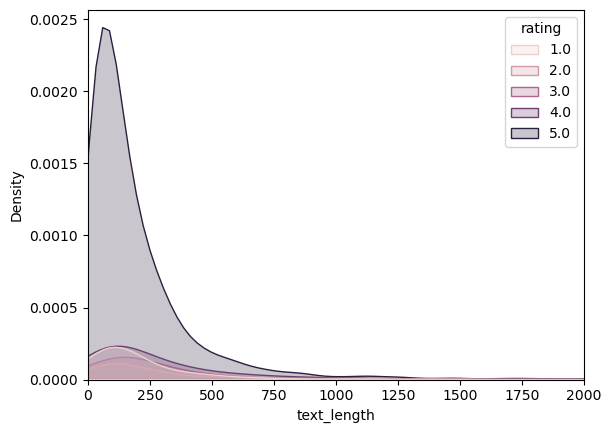

In [ ]:
# visaulize text length distribution among different product ratings
sns.kdeplot(final_df, x="text_length", hue="rating", fill=True)
plt.xlim(0, 2000)

plt.show()

Reviews per category

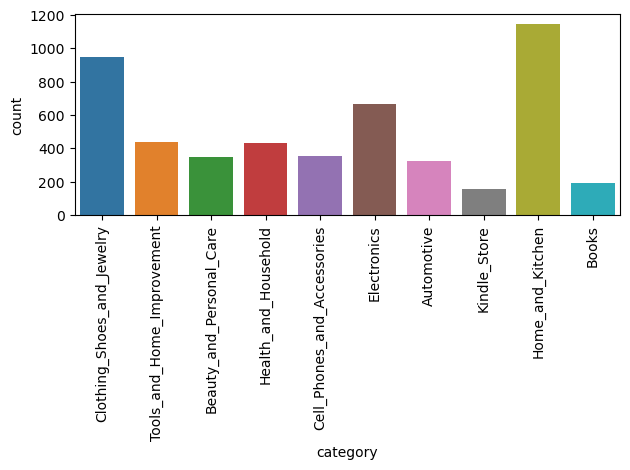

In [ ]:
# plot review count per category
sns.countplot(final_df, x="category", hue="category")
# rotate x-Axis
plt.xticks(rotation=90)
plt.tight_layout() 
plt.show()

Save Final dataframe

In [ ]:
# save the final dataframe 
final_df.to_csv("/Users/philipp/desktop/ML_in_Applied_Settings/human_reviews_labeled.csv", index=False, encoding="utf-8", sep="\t")